In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ==============================================================================
# [1] Recursive JSON Parser
# ==============================================================================
def load_all_benchmark_results(results_dir="../results"):
    """
    Recursively explores all JSON files under the results directory 
    and integrates them into a single DataFrame.
    """
    records = []
    
    search_pattern = os.path.join(results_dir, "**", "*.json")
    json_files = glob.glob(search_pattern, recursive=True)
    
    for file_path in json_files:
        with open(file_path, 'r') as f:
            try:
                data = json.load(f)
            except json.JSONDecodeError:
                continue
            
        model = data.get('model', 'UNKNOWN')
        dataset = data.get('dataset', 'unknown_data')
        n = data.get('N', 0)
        seed = data.get('seed', 0)
        
        meta_info = data.get('meta_info', {})
        
        if model == "SING":
            p_val = meta_info.get("p_order", "?") if isinstance(meta_info, dict) else "?"
            method_name = f"SING (p={p_val})"
        else:
            method_name = model
            
        metrics = data.get('metrics', {})
        
        total_time = data.get('execution_time_sec', np.nan)
        train_time = np.nan
        infer_time = np.nan
        
        # Type safeguard for meta_info to prevent TypeError
        if isinstance(meta_info, dict) and 'time_breakdown' in meta_info:
            time_bd = meta_info['time_breakdown']
            if isinstance(time_bd, dict):
                train_time = time_bd.get('training_seconds', np.nan)
                infer_time = time_bd.get('inference_seconds', np.nan)
        
        records.append({
            'Method': method_name,
            'Dataset': dataset,
            'N': n,
            'Seed': seed,
            'Hamming': metrics.get('Hamming', np.nan) if isinstance(metrics, dict) else np.nan,
            'TPR': metrics.get('TPR', np.nan) if isinstance(metrics, dict) else np.nan,
            'FDR': metrics.get('FDR', np.nan) if isinstance(metrics, dict) else np.nan,
            'Total_Time': total_time,
            'Train_Time': train_time,
            'Infer_Time': infer_time
        })
        
    df = pd.DataFrame(records)
    return df



# Figure —  graph estimation results under various sample sizes

Saved: ../figures/combined_dim20_4datasets_3x4.pdf
Saved: ../figures/combined_dim20_4datasets_3x4.png


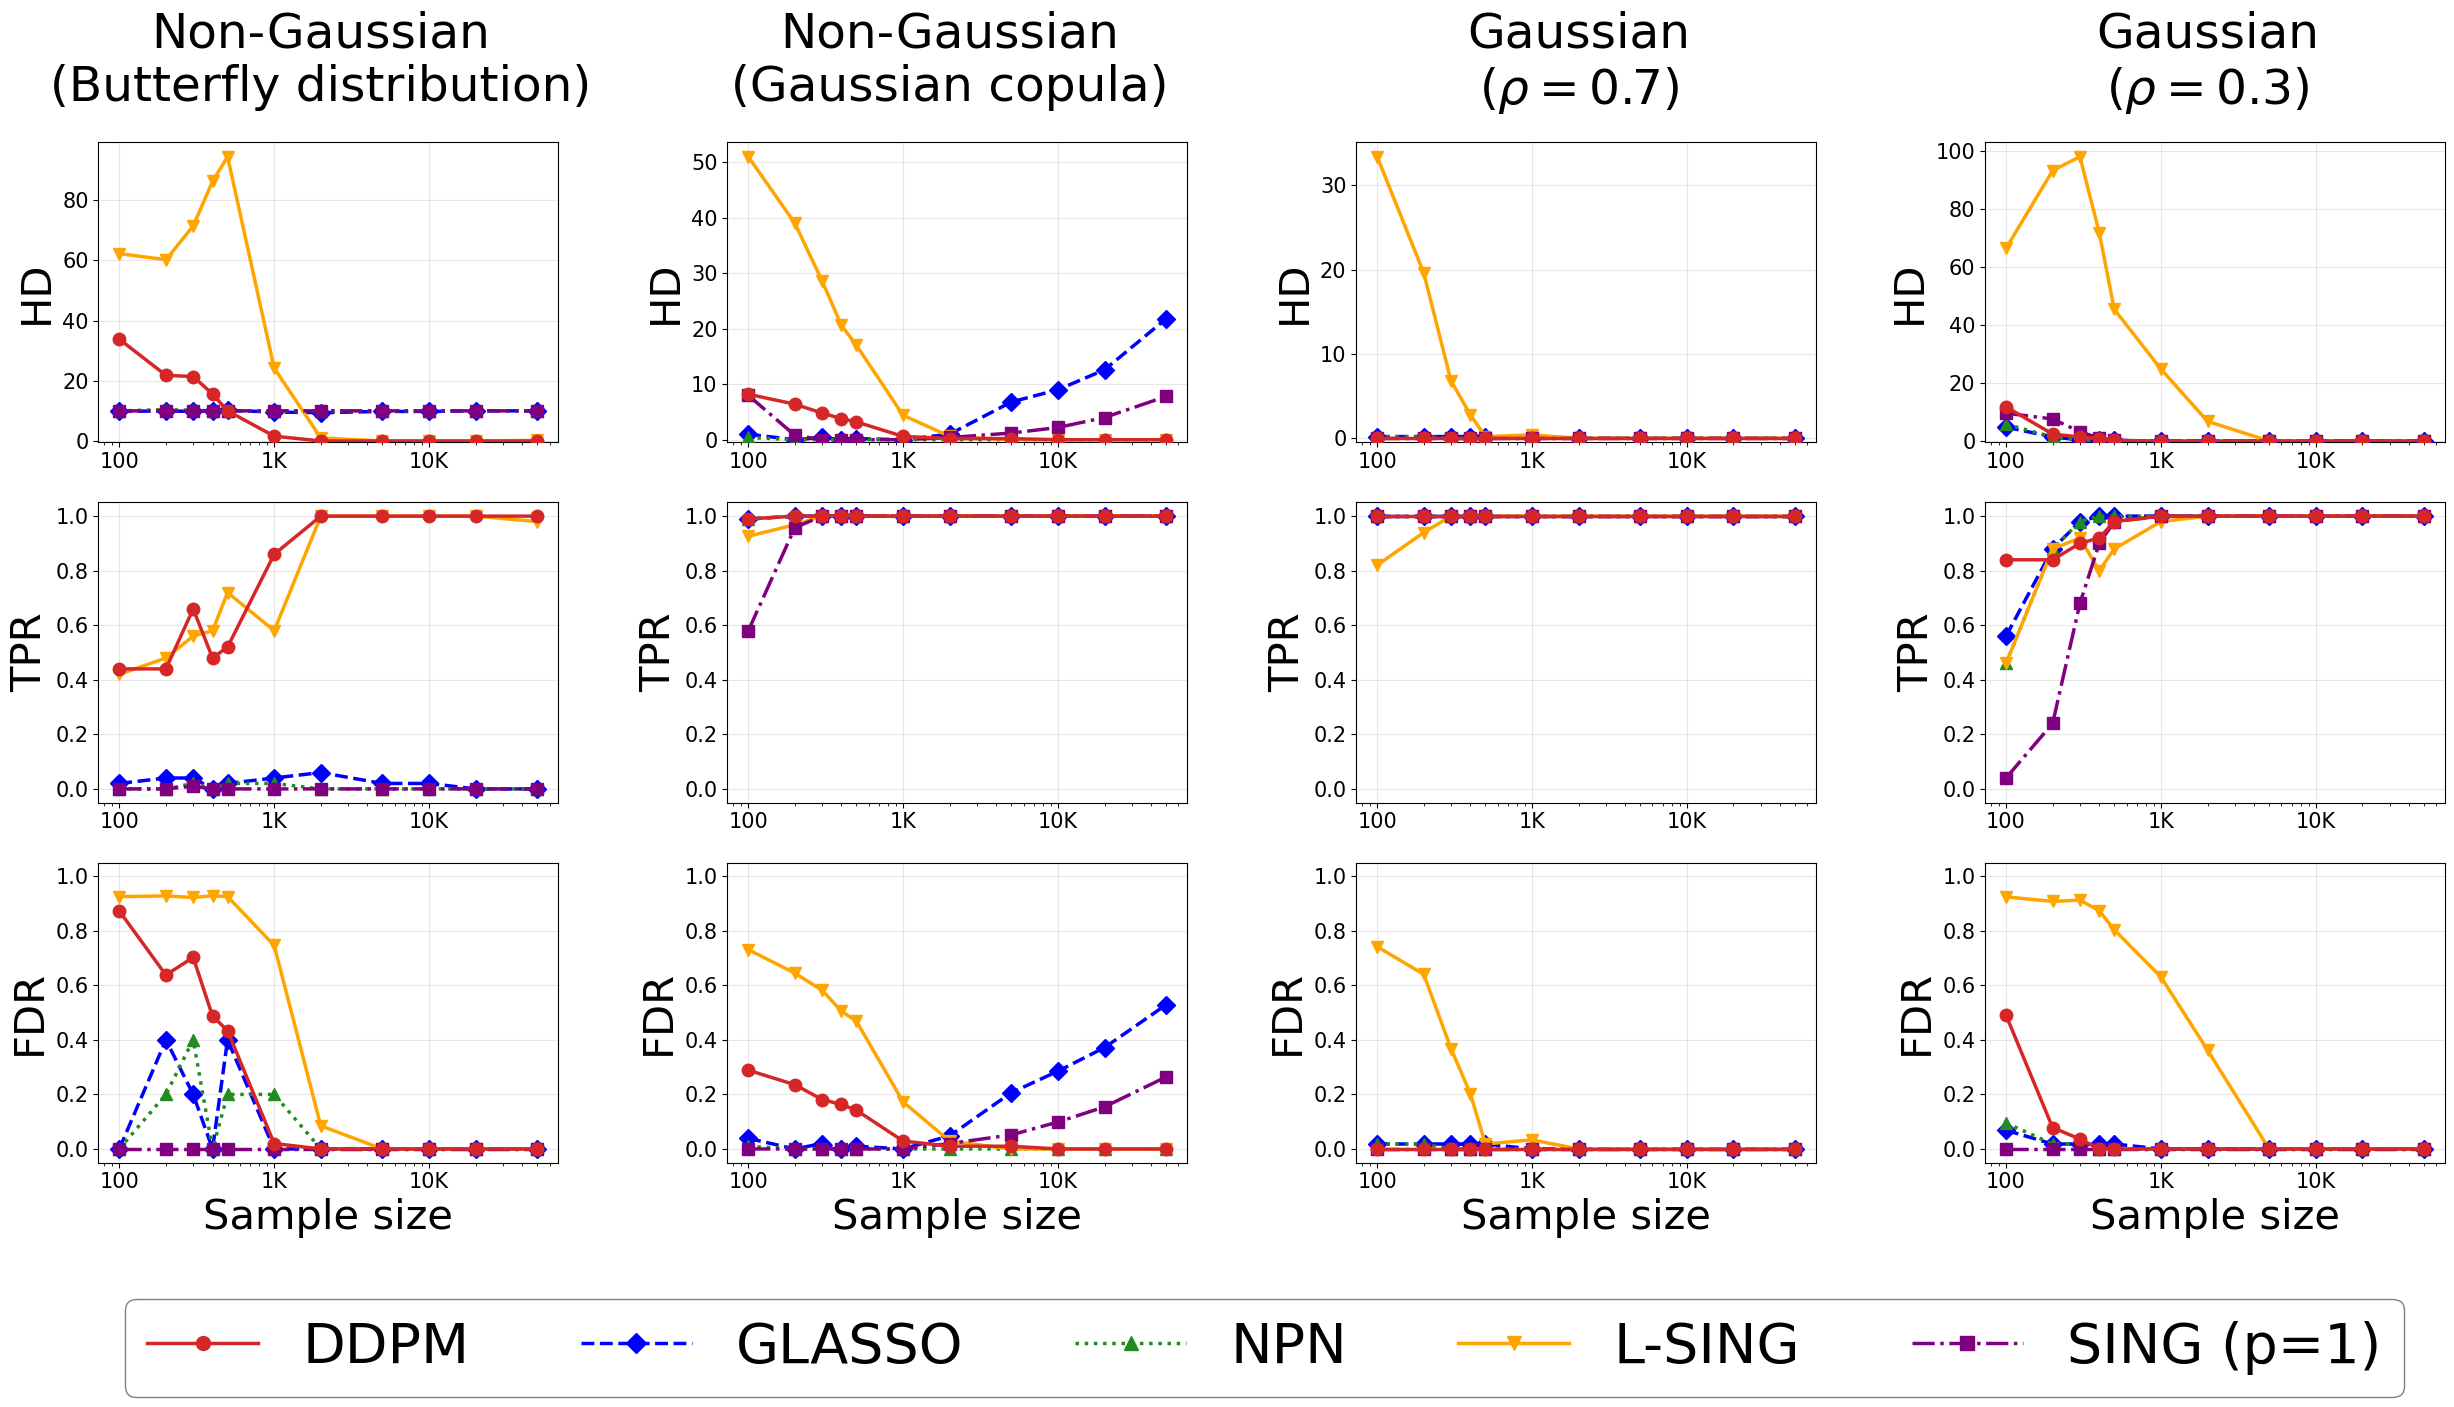

In [2]:
from matplotlib.lines import Line2D


def plot_4dataset_combined(df_all, target_datasets,
                           save_dir=None, save_formats=("pdf", "png"), dpi=300,
                           filename="combined_dim20_4datasets"):
    """3 metrics (rows) x len(target_datasets) datasets (cols), shared bottom legend.

    `df_all` is the DataFrame from `load_all_benchmark_results`; each column is
    filtered to one dataset. Only methods present for a dataset are drawn.
    """
    plt.rcParams.update({
        'font.size': 16, 'axes.labelsize': 30, 'axes.titlesize': 30,
        'xtick.labelsize': 15, 'ytick.labelsize': 15, 'legend.fontsize': 40,
    })

    dataset_mapping = {
        "dim20_butterfly": "Non-Gaussian\n(Butterfly distribution)",
        "dim20_cop_gau": "Non-Gaussian\n(Gaussian copula)",
        "0.1_dim20_pair_gau": "Gaussian\n" + r"$(\rho=0.1)$",
        "0.3_dim20_pair_gau": "Gaussian\n" + r"$(\rho=0.3)$",
        "0.5_dim20_pair_gau": "Gaussian\n" + r"$(\rho=0.5)$",
        "0.7_dim20_pair_gau": "Gaussian\n" + r"$(\rho=0.7)$",
    }
    metrics = ['Hamming', 'TPR', 'FDR']
    y_labels = ['HD', 'TPR', 'FDR']

    style_map = {
        'DDPM':       {'color': 'tab:red',    'marker': 'o', 'linestyle': '-'},
        'GLASSO':     {'color': 'blue',       'marker': 'D', 'linestyle': '--'},
        'NPN':        {'color': 'forestgreen','marker': '^', 'linestyle': ':'},
        'LSING':      {'color': 'orange',     'marker': 'v', 'linestyle': '-'},
        'SING (p=1)': {'color': 'purple',     'marker': 's', 'linestyle': '-.'},
        'SING (p=2)': {'color': 'darkviolet', 'marker': 'X', 'linestyle': '--'},
        'SING (p=3)': {'color': 'magenta',    'marker': 'P', 'linestyle': ':'},
    }
    logical_order = ['DDPM', 'GLASSO', 'NPN', 'LSING', 'SING (p=1)']

    n_metrics = len(metrics)
    n_cols = len(target_datasets)

    fig = plt.figure(figsize=(6.2 * n_cols, 4.3 * n_metrics + 1.0))
    data_sf, legend_sf = fig.subfigures(
        2, 1, height_ratios=[4.3 * n_metrics, 0.5], hspace=0.02)
    column_sfs = data_sf.subfigures(1, n_cols, wspace=0.06)

    all_present_methods = set()

    for j in range(n_cols):
        col_sf = column_sfs[j]
        dataset = target_datasets[j]
        if dataset in dataset_mapping:
            col_sf.suptitle(dataset_mapping[dataset], fontsize=35, y=0.98)

        axes_col = col_sf.subplots(n_metrics, 1)

        df = df_all[df_all['Dataset'] == dataset]
        if df.empty:
            print(f"Warning: no results for {dataset} - leaving column empty")
            for ax in axes_col:
                ax.set_visible(False)
            continue

        present_methods = [m for m in logical_order if m in df['Method'].unique()]
        all_present_methods.update(present_methods)

        for i, metric in enumerate(metrics):
            ax = axes_col[i]
            for method in present_methods:
                agg_df = df[df['Method'] == method].groupby('N')[metric].mean().reset_index()
                style = style_map[method]
                ax.plot(
                    agg_df['N'], agg_df[metric],
                    color=style['color'], marker=style['marker'], linestyle=style['linestyle'],
                    linewidth=2.5, markersize=9,
                    zorder=10 if method == 'DDPM' else 3,
                )

            ax.set_ylabel(y_labels[i])
            if i == n_metrics - 1:
                ax.set_xlabel("Sample size")
            ax.set_xscale('log')
            ax.xaxis.set_major_formatter(
                ticker.FuncFormatter(lambda x, pos: f"{int(x / 1000)}K" if x >= 1000 else str(int(x))))
            ax.grid(True, alpha=0.3)

            if metric in ['TPR', 'FDR']:
                ax.set_ylim(-0.05, 1.05)
            elif metric == 'Hamming':
                ax.set_ylim(bottom=-0.5)

    # Shared legend at the bottom subfigure
    present_methods_ordered = [m for m in logical_order if m in all_present_methods]
    legend_handles = [
        Line2D([0], [0], color=style_map[m]['color'], marker=style_map[m]['marker'],
               linestyle=style_map[m]['linestyle'], linewidth=2.5, markersize=10)
        for m in present_methods_ordered
    ]
    legend_labels = ["L-SING" if m == "LSING" else m for m in present_methods_ordered]
    legend_sf.legend(legend_handles, legend_labels, loc='center',
                     ncol=max(1, len(legend_labels)), frameon=True,
                     fancybox=True, framealpha=1.0, edgecolor='gray')

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        for ext in save_formats:
            out_path = os.path.join(save_dir, f"{filename}.{ext}")
            fig.savefig(out_path, dpi=dpi, bbox_inches='tight')
            print(f"Saved: {out_path}")

    plt.show()
    plt.close(fig)


df_all = load_all_benchmark_results(results_dir="../results")

target_datasets_4 = [
    "dim20_butterfly",
    "dim20_cop_gau",
    "0.7_dim20_pair_gau",
    "0.3_dim20_pair_gau",
]
plot_4dataset_combined(
    df_all, target_datasets_4,
    save_dir="../figures", save_formats=("pdf", "png"), dpi=300,
    filename="combined_dim20_4datasets_3x4",
)


[Visualization] dim5_cop_gau


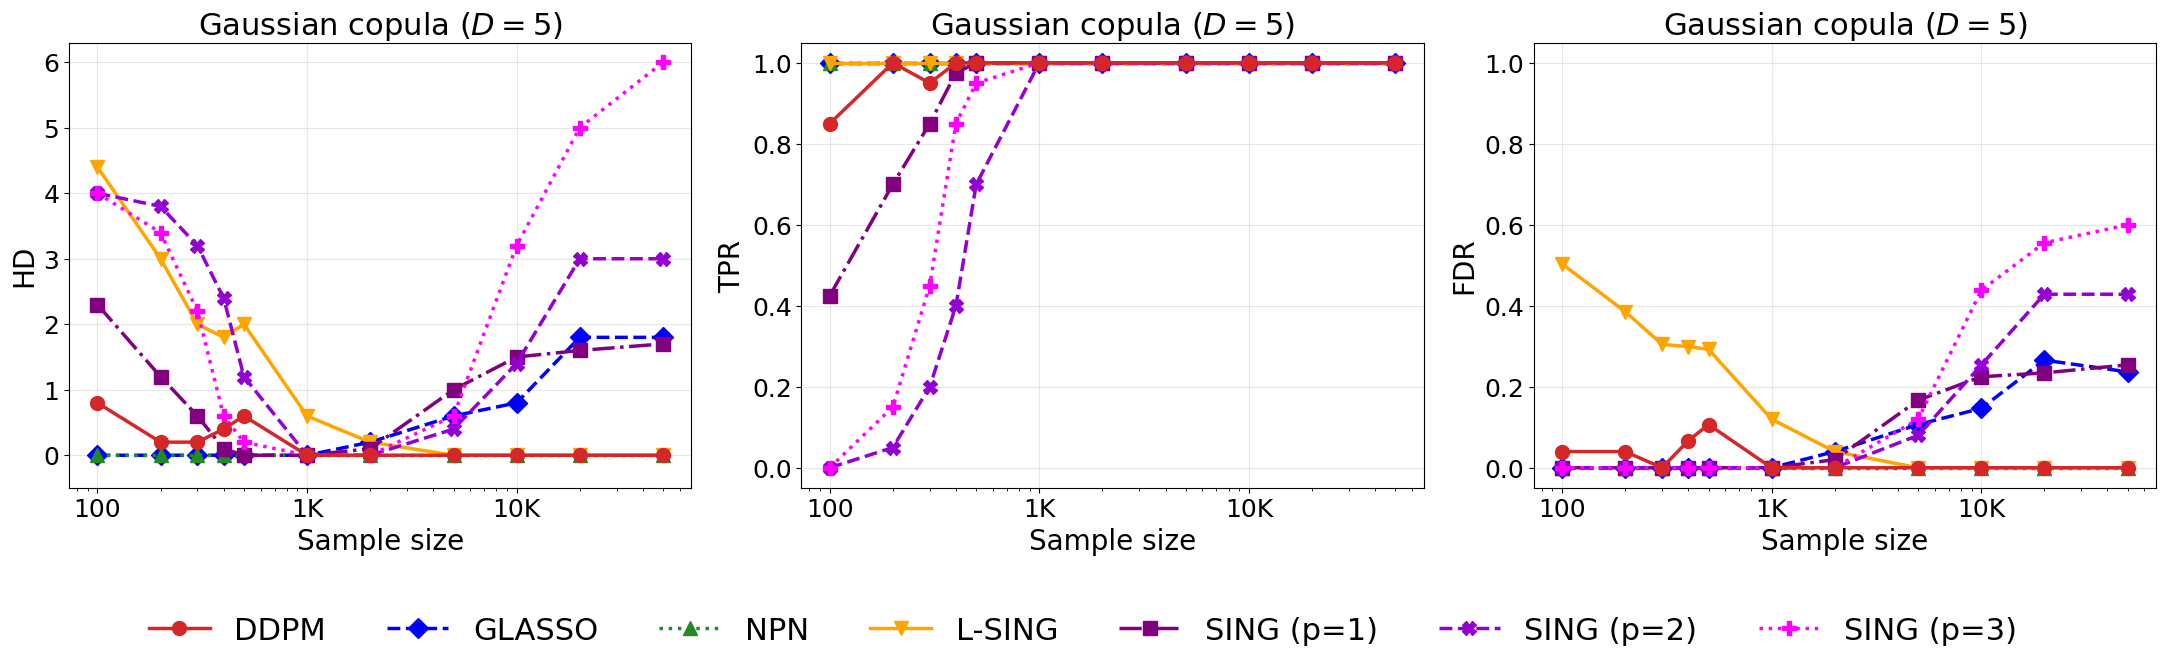


[Visualization] dim6_butterfly


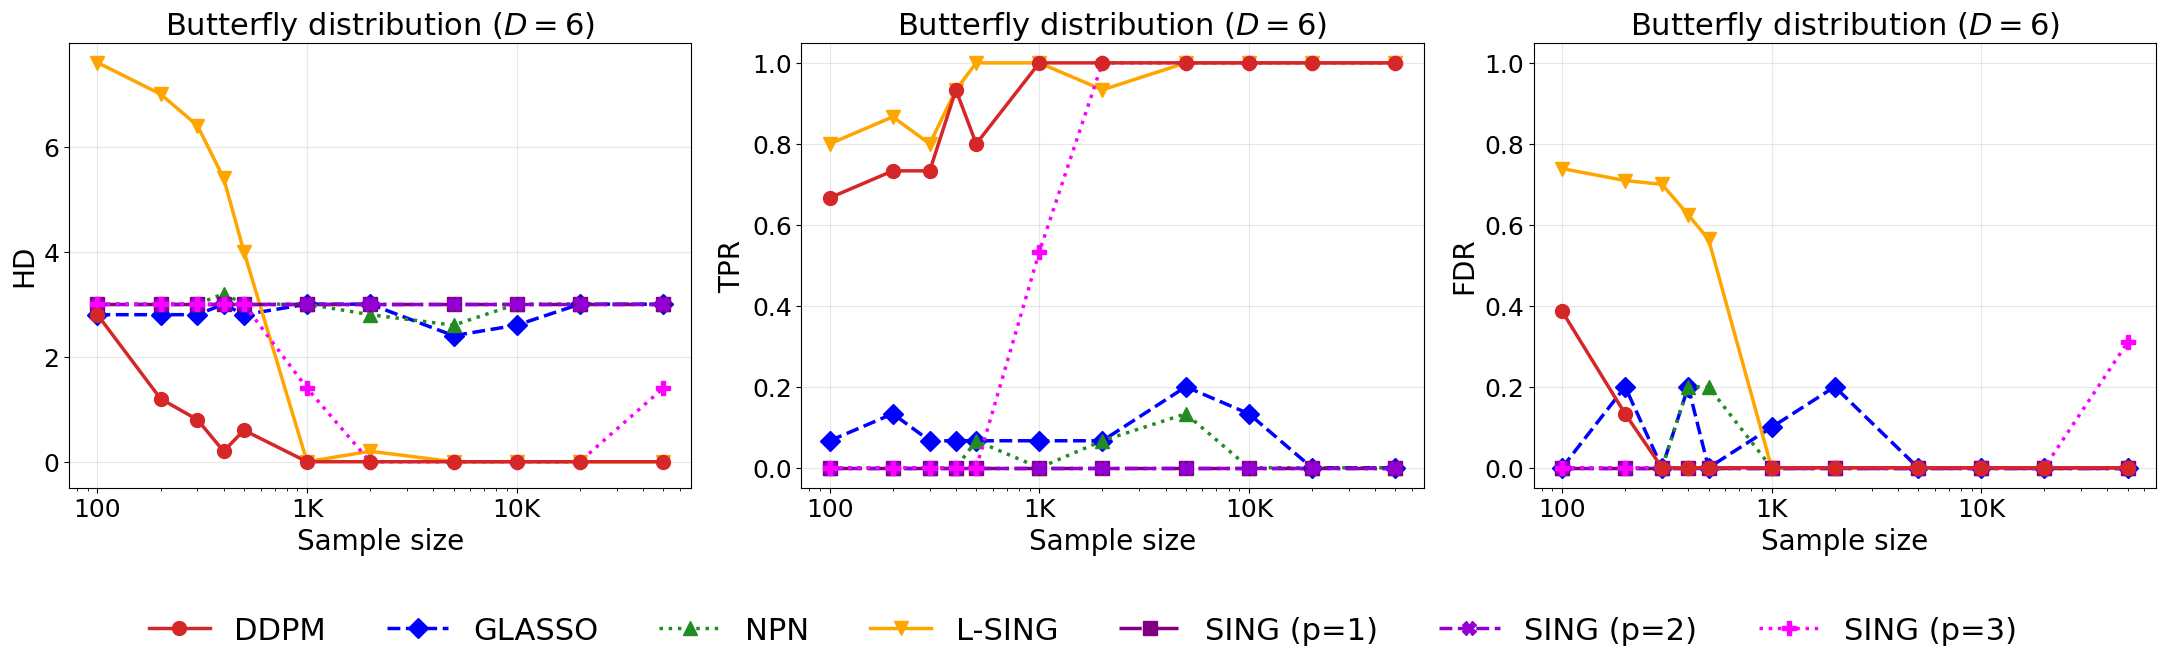

In [3]:
# ==============================================================================
# 1x3 metric plot (HD / TPR / FDR) for a single dataset — 0424 style
# ==============================================================================
def plot_metrics_1x3(df_all, dataset_name):
    df_sub = df_all[df_all['Dataset'] == dataset_name]
    if df_sub.empty:
        print(f"[skip] {dataset_name}: no results")
        return

    plt.rcParams.update({
        'font.size': 18, 'axes.labelsize': 20, 'axes.titlesize': 22,
        'xtick.labelsize': 18, 'ytick.labelsize': 18, 'legend.fontsize': 22,
    })

    dataset_mapping = {
        "dim5_cop_gau": r"Gaussian copula $(D=5)$",
        "dim6_butterfly": r"Butterfly distribution $(D=6)$",
        "dim6_pair_gau": r"Gaussian pair $(D=6)$",
        "dim20_butterfly": r"Butterfly distribution",
        "dim20_cop_gau": r"Gaussian copula",
        "dim20_pair_gau": r"Gaussian pair $(D=20)$",
        "0.1_dim20_pair_gau": r"Gaussian pair $(\rho=0.1)$",
        "0.3_dim20_pair_gau": r"Gaussian pair $(\rho=0.3)$",
        "0.5_dim20_pair_gau": r"Gaussian pair $(\rho=0.5)$",
        "0.7_dim20_pair_gau": r"Gaussian pair $(\rho=0.7)$",
    }
    title = dataset_mapping.get(dataset_name, dataset_name)

    metrics = ['Hamming', 'TPR', 'FDR']
    y_labels = ['HD', 'TPR', 'FDR']

    style_map = {
        'DDPM':       {'color': 'tab:red',    'marker': 'o', 'linestyle': '-'},
        'GLASSO':     {'color': 'blue',       'marker': 'D', 'linestyle': '--'},
        'NPN':        {'color': 'forestgreen','marker': '^', 'linestyle': ':'},
        'LSING':      {'color': 'orange',     'marker': 'v', 'linestyle': '-'},
        'SING (p=1)': {'color': 'purple',     'marker': 's', 'linestyle': '-.'},
        'SING (p=2)': {'color': 'darkviolet', 'marker': 'X', 'linestyle': '--'},
        'SING (p=3)': {'color': 'magenta',    'marker': 'P', 'linestyle': ':'},
    }
    logical_order = ['DDPM', 'GLASSO', 'NPN', 'LSING', 'SING (p=1)', 'SING (p=2)', 'SING (p=3)']
    present_methods = [m for m in logical_order if m in df_sub['Method'].unique()]

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    for i, metric in enumerate(metrics):
        ax = axes[i]
        for method in present_methods:
            agg_df = df_sub[df_sub['Method'] == method].groupby('N')[metric].mean().reset_index()
            style = style_map[method]
            label = 'L-SING' if method == 'LSING' else method
            ax.plot(
                agg_df['N'], agg_df[metric],
                label=label, color=style['color'], marker=style['marker'],
                linestyle=style['linestyle'], linewidth=2.5, markersize=10,
                zorder=10 if method == 'DDPM' else 3,
            )
        ax.set_title(title)
        ax.set_xlabel("Sample size")
        ax.set_ylabel(y_labels[i])
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}K" if x >= 1000 else str(int(x))))
        ax.grid(True, alpha=0.3)
        if metric in ['TPR', 'FDR']:
            ax.set_ylim(-0.05, 1.05)
        elif metric == 'Hamming':
            ax.set_ylim(bottom=-0.5)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.15),
               ncol=len(present_methods), frameon=False)
    plt.tight_layout()
    plt.show()


df_all = load_all_benchmark_results(results_dir="../results")

for dataset in ["dim5_cop_gau", "dim6_butterfly"]:
    print(f"\n{'=' * 80}\n[Visualization] {dataset}\n{'=' * 80}")
    plot_metrics_1x3(df_all, dataset)

## Figure — $\widetilde H_{ij}(t)$ for Gaussian copula with $n = 100$ (left) and $n = 1000$ (right).

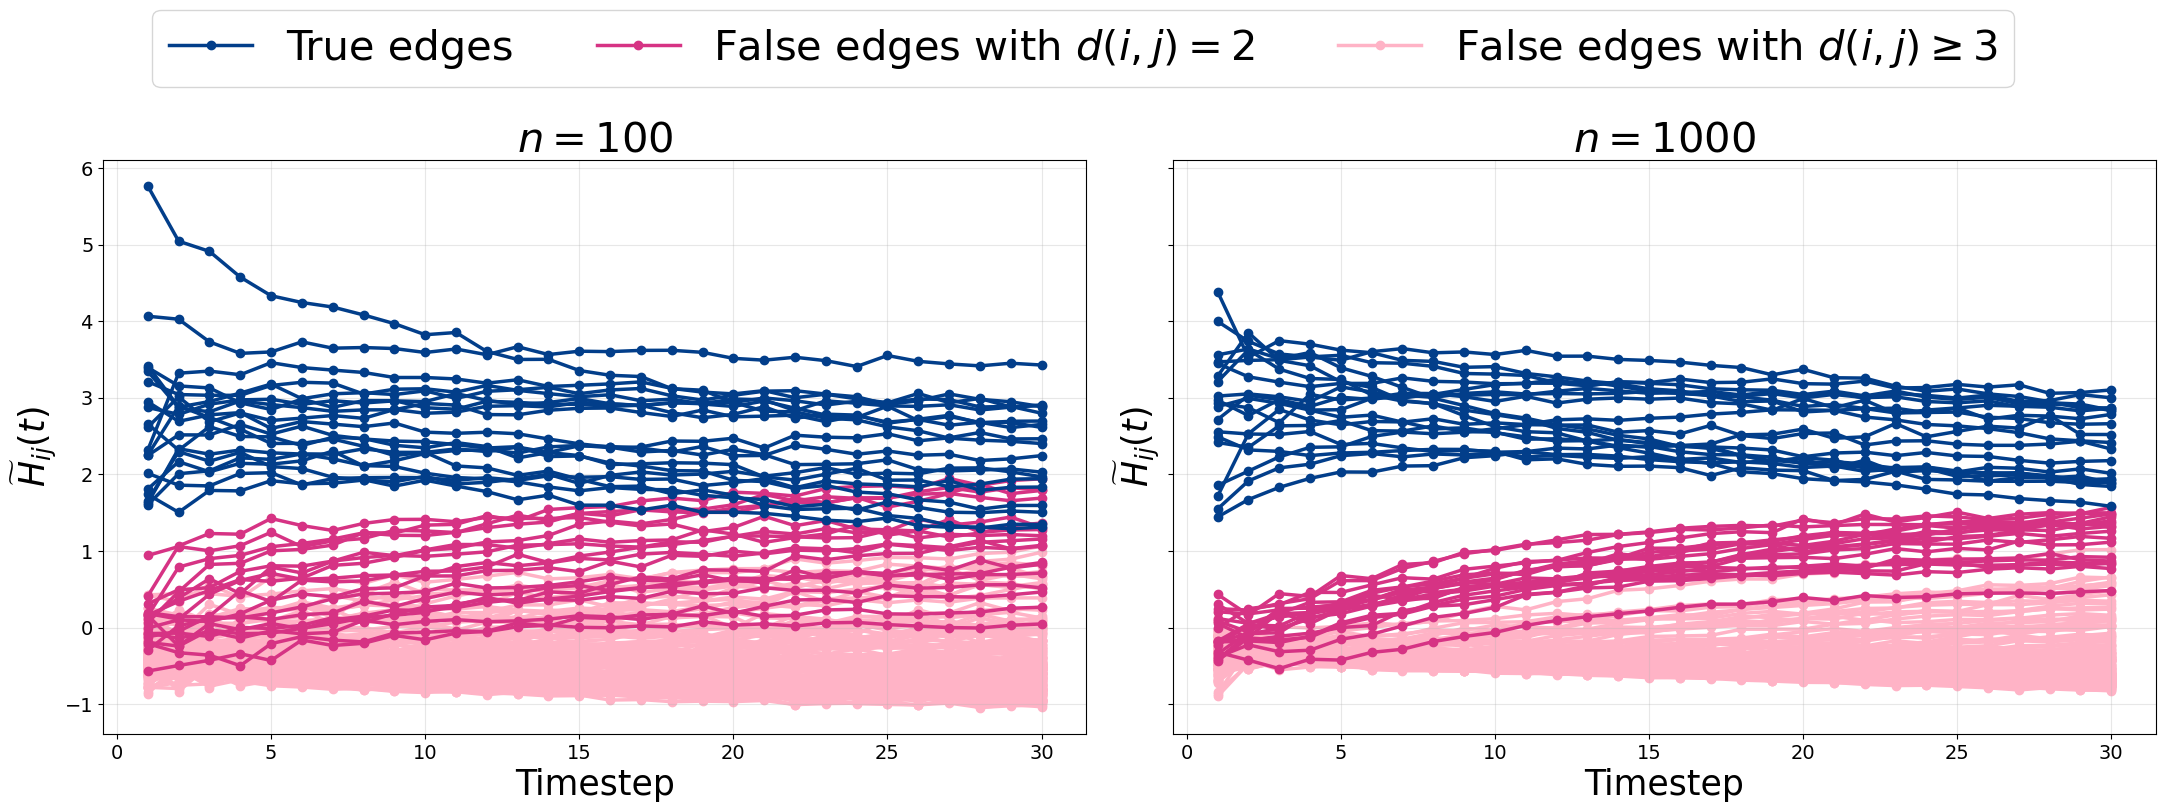

In [4]:
import pickle

# Gaussian-copula chain ground truth: i -- i+1
def make_chain_adj_matrix(D):
    A = np.zeros((D, D), dtype=int)
    for i in range(D - 1):
        A[i, i + 1] = A[i + 1, i] = 1
    return A


def standardize_H_dict(H_dict_avg, t_list):
    """Per-timestep z-score of the off-diagonal Hessian entries."""
    D = H_dict_avg[t_list[0]].shape[1]
    H_std_dict = {}
    for t in t_list:
        H_t = H_dict_avg[t]
        off_diag = [H_t[i, j] for i in range(D) for j in range(i + 1, D)]
        mu, sigma = np.mean(off_diag), np.std(off_diag, ddof=0)
        H_std_dict[t] = (H_t - mu) / sigma if sigma > 1e-12 else (H_t - mu)
    return H_std_dict


CAT_COLOR = {'true': '#023e8a', 'false_d2': '#d63384', 'false_dge3': '#ffb3c6'}
CAT_LABEL = {
    'true': 'True edges',
    'false_d2': r'False edges with $d(i,j)=2$',
    'false_dge3': r'False edges with $d(i,j)\geq 3$',
}
CAT_ZORDER = {'false_dge3': 1, 'false_d2': 2, 'true': 3}


def draw_hessian_panel(ax, H_dict, t_list, true_adj, subtitle):
    D = H_dict[t_list[0]].shape[1]
    for i in range(D):
        for j in range(i + 1, D):
            if true_adj[i, j] == 1:
                cat = 'true'
            else:
                cat = 'false_d2' if abs(i - j) == 2 else 'false_dge3'
            ax.plot(t_list, [H_dict[t][i, j] for t in t_list], marker='o',
                    color=CAT_COLOR[cat], linewidth=2.5, zorder=CAT_ZORDER[cat])
    ax.set_title(subtitle)
    ax.set_xlabel("Timestep")
    ax.set_ylabel(r"$\widetilde H_{ij}(t)$")
    ax.grid(True, alpha=0.3)


seed = 120
dataset = "dim20_cop_gau"
data_sizes = [100, 1000]
t_list = list(range(1, 31))

plt.rcParams.update({
    "font.size": 18, "axes.titlesize": 30, "axes.labelsize": 25,
    "xtick.labelsize": 14, "ytick.labelsize": 14, "legend.fontsize": 30,
    "text.usetex": False,
})

fig, axes = plt.subplots(1, 2, figsize=(22, 8), sharey=True)
for ax, n in zip(axes, data_sizes):
    with open(f"./data/hessian_dim20_cop_gau/n{n}.pickle", "rb") as handle:
        H_dict_avg, _ = pickle.load(handle)
    D = H_dict_avg[t_list[0]].shape[1]
    true_adj = make_chain_adj_matrix(D)
    H_std = standardize_H_dict(H_dict_avg, t_list)
    draw_hessian_panel(ax, H_std, t_list, true_adj, subtitle=fr"$n={n}$")

legend_handles = [
    plt.Line2D([0], [0], marker='o', color=CAT_COLOR[c], linewidth=2.5, label=CAT_LABEL[c])
    for c in ('true', 'false_d2', 'false_dge3')
]
fig.legend(handles=legend_handles, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.1))
fig.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()